100%|██████████| 12000/12000 [3:53:10<00:00,  1.17s/it]


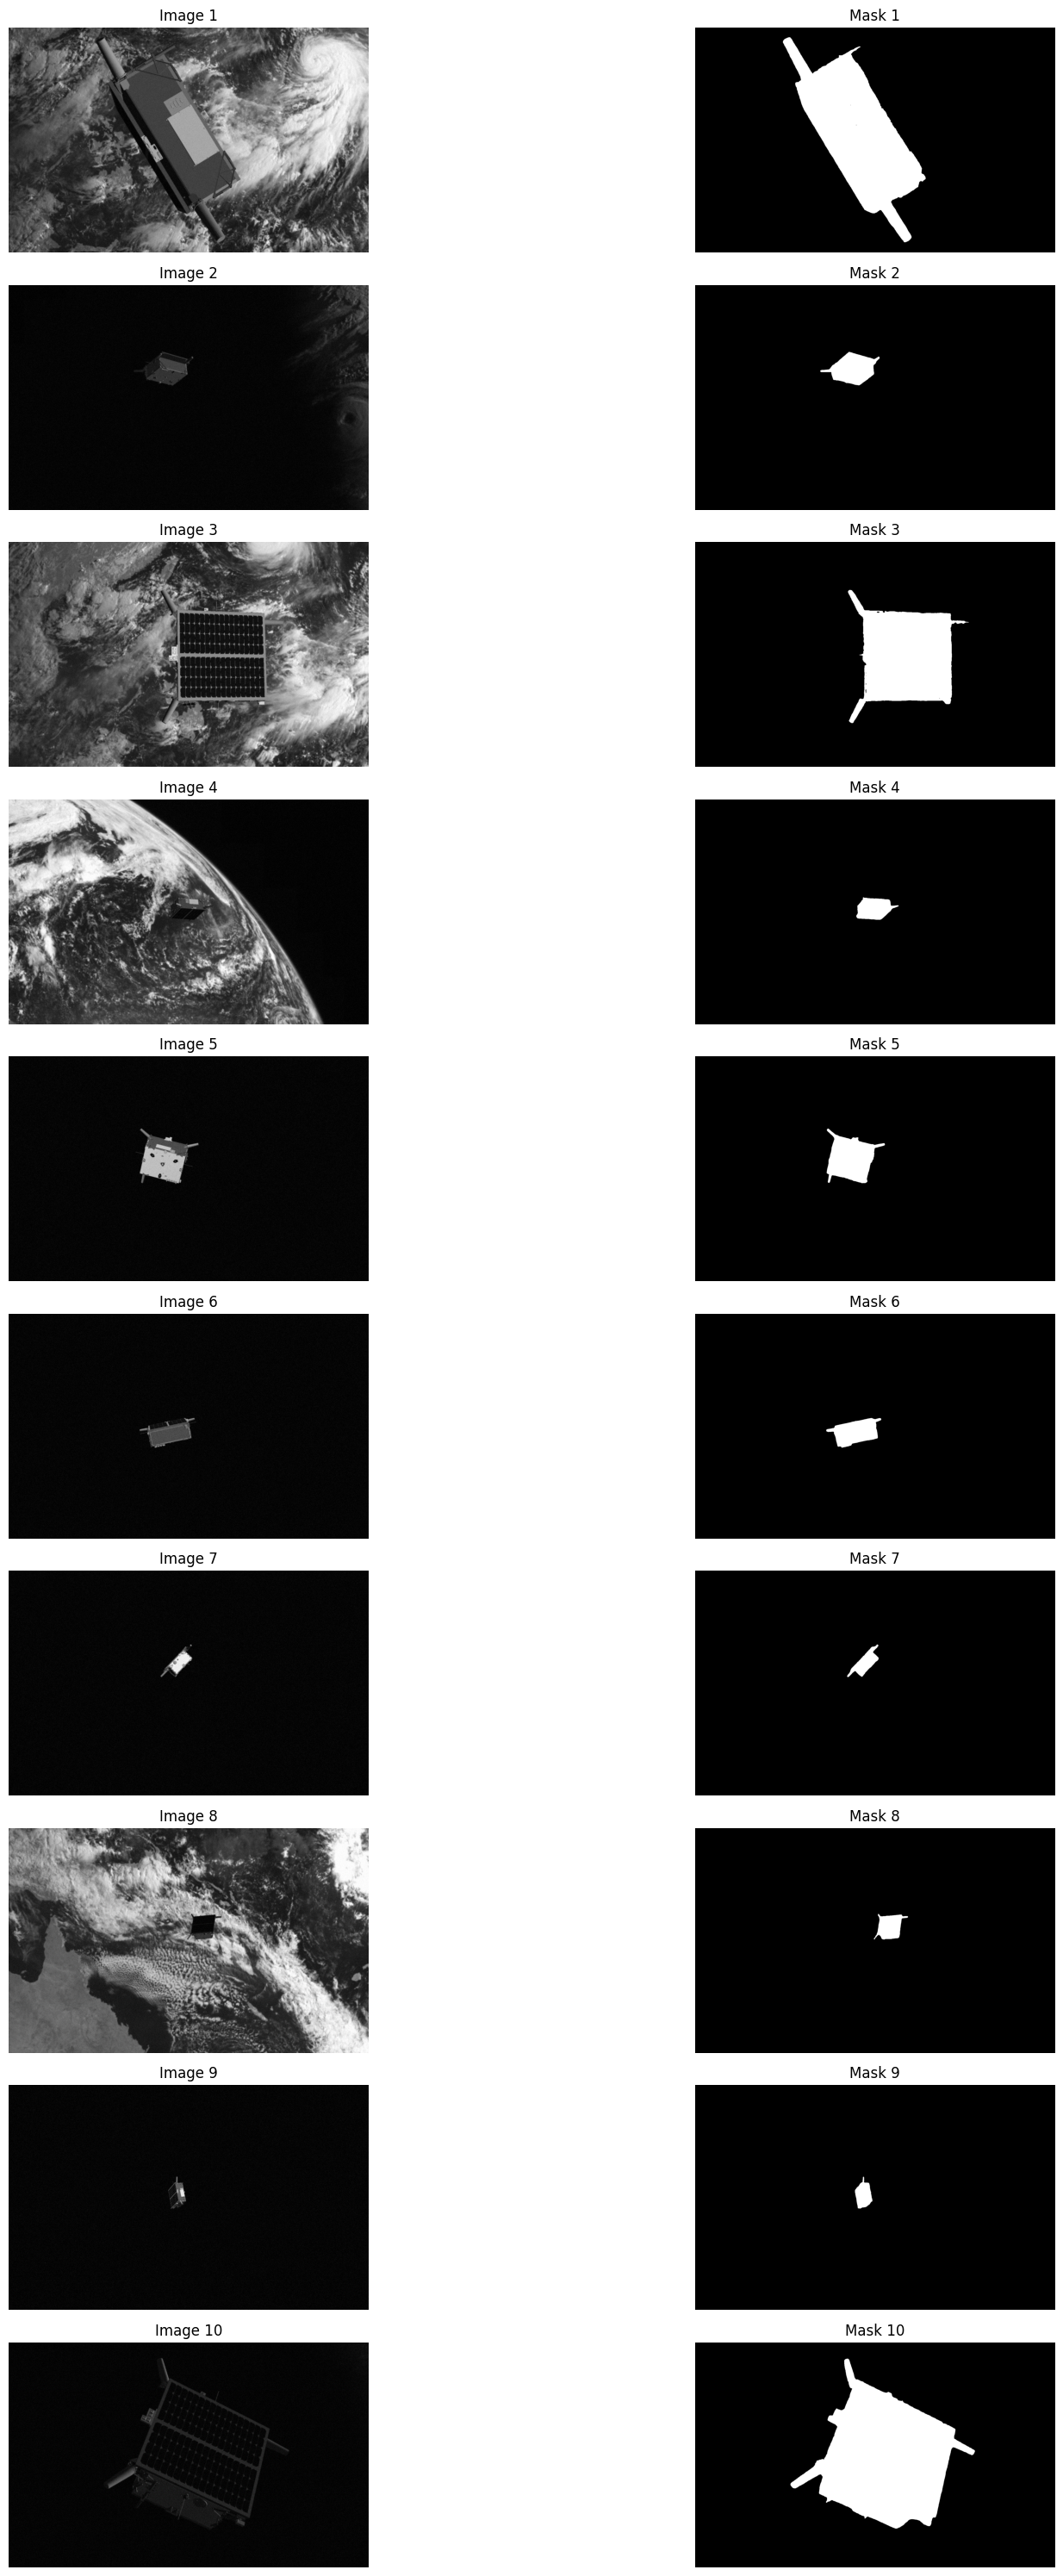

100%|██████████| 5/5 [00:05<00:00,  1.14s/it]


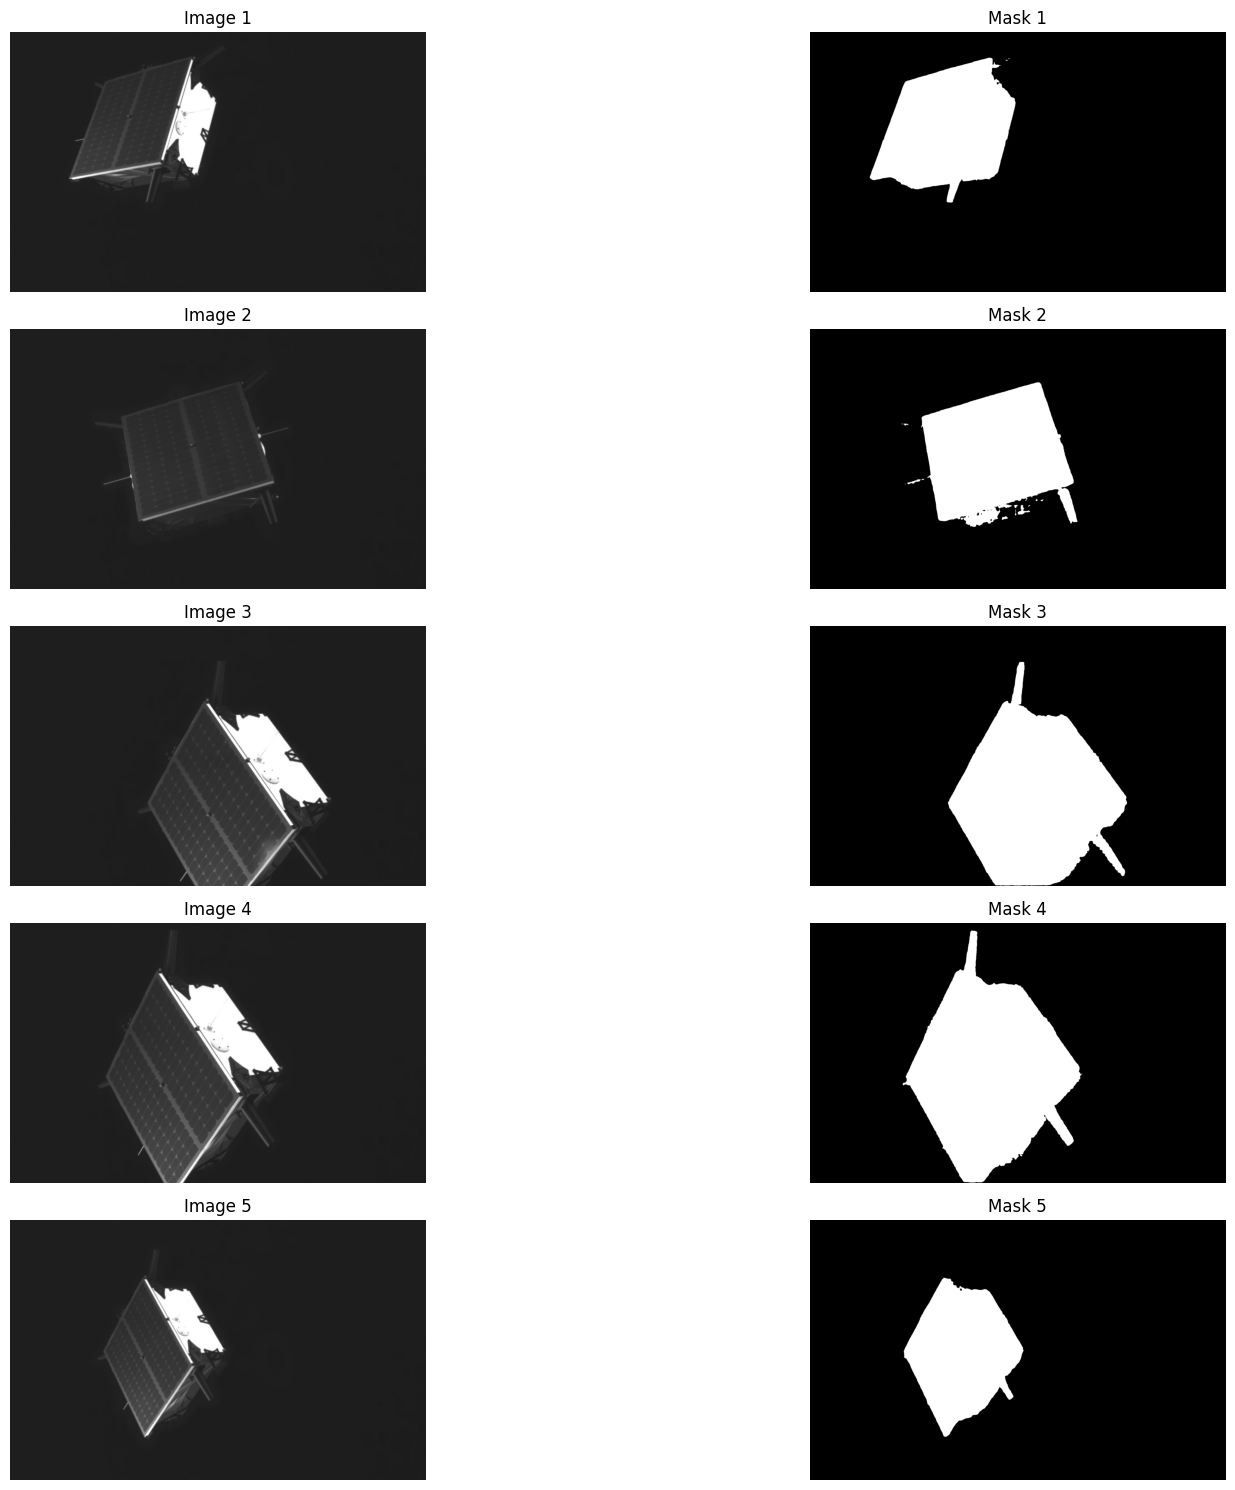

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from scipy.io import loadmat
import numpy as np
import tqdm
import cv2
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

class Speed(Dataset):
    def __init__(self, images_dir, masks_dir, train_json_dir, val_json_dir=None , transform=None):
        self.images_dir = images_dir
        self.train_json_dir = train_json_dir
        self.val_json_dir = val_json_dir
        self.masks_dir = masks_dir 
        self.imagesPathList = []
        self.masksPathList = []
        self.transform = transform
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.sam = sam_model_registry["vit_h"](checkpoint="/kaggle/input/samfacebook/sam_vit_h_4b8939.pth")
        self.sam.to(self.device)
        
        # Replace mask generator with predictor
        self.predictor = SamPredictor(self.sam)

        if not os.path.exists(masks_dir):
            os.makedirs(masks_dir)
        
        cnt=0

        keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        cameraMatrix, distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        with open(self.train_json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }
            
        if self.val_json_dir:
            with open(self.val_json_dir, 'r') as f:
                val_annotations = json.load(f)
                for item in val_annotations:
                    lookup[item['filename']] = item

        for filename in tqdm.tqdm(os.listdir(self.images_dir)):
            if filename not in lookup:
                continue
            image_path = os.path.join(self.images_dir, filename)
            self.imagesPathList.append(image_path)

            mask_filename = os.path.splitext(filename)[0] + ".png"
            mask_path = os.path.join(self.masks_dir, mask_filename)
            self.masksPathList.append(mask_path)

            q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
            r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

            keypts2d = project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypts3d) # (2, 11)
            xmin = np.min(keypts2d[0])
            xmax = np.max(keypts2d[0])
            ymin = np.min(keypts2d[1])
            ymax = np.max(keypts2d[1])

            width = xmax - xmin
            height = ymax - ymin
            margin_x = width * 0.05
            margin_y = height * 0.05

            xmin = max(0, xmin - margin_x)
            xmax = xmax + margin_x
            ymin = max(0, ymin - margin_y)
            ymax = ymax + margin_y

            BBox = [xmin, xmax, ymin, ymax]

            if not os.path.exists(mask_path):
                mask = self.create_spacecraft_mask(image_path, BBox)
                cv2.imwrite(mask_path, (mask * 255).astype(np.uint8))  

            cnt=cnt+1
            # if cnt>10:
            #     break

    def create_spacecraft_mask(self, image_path, BBox):
        # Load image
        original_image = cv2.imread(image_path)
        original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        
        self.predictor.set_image(original_image)
        
        input_box = np.array([
            int(BBox[0]),  
            int(BBox[2]),  
            int(BBox[1]),  
            int(BBox[3])   
        ])
        
        masks, _, _ = self.predictor.predict(
            box=input_box[None, :],
            multimask_output=False  
        )
        
        final_mask = masks[0]
        
        return final_mask

    def __len__(self):
        return len(self.imagesPathList)

    def __getitem__(self, idx):
        image_path = self.imagesPathList[idx]
        image = Image.open(image_path).convert('RGB')
        mask_path = self.masksPathList[idx]
        mask = Image.open(mask_path).convert('L')

        return image, mask


dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/trainval', 
                masks_dir='/kaggle/working/speedsplit/speed/masks/trainval',  
                train_json_dir='/kaggle/input/speedsplit/speed/train.json',
                val_json_dir='/kaggle/input/speedsplit/speed/val.json',
                )

num_images = min(10, len(dataset))

plt.figure(figsize=(20, num_images * 3))

for i in range(num_images):
    image, mask = dataset[i]
    
    plt.subplot(num_images, 2, 2 * i + 1)
    plt.imshow(np.array(image))
    plt.title(f'Image {i+1}')
    plt.axis('off')
    
    plt.subplot(num_images, 2, 2 * i + 2)
    plt.imshow(np.array(mask), cmap='gray')
    plt.title(f'Mask {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

real_dataset = Speed(images_dir='/kaggle/input/speedsplit/speed/images/real', 
                masks_dir='/kaggle/working/speedsplit/speed/masks/real',  
                train_json_dir='/kaggle/input/speedsplit/speed/real.json',
                val_json_dir = None
                )

num_images = min(10, len(real_dataset))

plt.figure(figsize=(20, num_images * 3))

for i in range(num_images):
    image, mask = real_dataset[i]
    
    plt.subplot(num_images, 2, 2 * i + 1)
    plt.imshow(np.array(image))
    plt.title(f'Image {i+1}')
    plt.axis('off')
    
    plt.subplot(num_images, 2, 2 * i + 2)
    plt.imshow(np.array(mask), cmap='gray')
    plt.title(f'Mask {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()